# Aprendizado de representação e aprendizado gerativo com autoencoder e GANs
Autoencoders são redes neurais artificiais capazes de aprender representações densas dos dados de entrada que se chamam _representações latentes_, ou _codificações_, sem qualquer supervisão (ou seja, o conjunto de treinamento não possui qualquer tipo de rótulo). Os autoencoders atuam também como detectores de características e podem ser utilizados para pré-treinamento não supervisionado de DNNs, capazes de gerar aleatoriamente novos dados que se parecem bastante com os dados de treinamento. Por exemplo, utilizar rostos para treinar o autoencoder faz com que podemos gerar novos rostos. Eles são bem ruins, mas funciona. Agora, rostos gerados por redes generativas adversativas (GANs) atualmente são bem convincentes.

Ambos são não supervisionados, no entanto funcionam de forma bem diferente:
- Autoencoders basicamente aprendem a copiar as entradas para as saídas, por exemplo: podemos limitar o tamanho das representações latentes ou adicionar ruído às entradas e treinar a rede para recurar as entradas originais. Resumindo, as codificações são derivadas do autoencoder que aprendem a função de identidade de acordo com algumas restrições.
- GANs são compostas de duas redes neurais, a generativa, que tenta gerar dados semelhantes aos dados de treinamento, e a discriminativa, que tenta distinguir os dados reais dos dados falsos. As redes competem entre si durante o treinamento.

## Representações de dados eficientes
No livro temos um exemplo de quais sequências de números são mais fáceis de interpretar, uma que possui numéros aleatórios ordenados também randomicamente, e outra que só possui uma sequência de números pares em progressão aritmética decrescente de razão 2. Para o autoencoder, ele observa as entradas e as converte em uma representação latente eficiente. em seguida, solta algo que se parece co as entradas. 

Um autoencoder é sempre composto de duas partes, o encoder, que converte as entradas em uma representação latente, seguido por um decoder, que converte a representação interna em saídas.

## Executando uma PCA com um autoencoder linear subcompleto
PCA (Principal Component Analysis) é uma técnica estatística de redução de dimensionalidade não supervisionada. Se o autoencoder usar somente ativações lineares e a função de custo for o MSE, ele acaba realizando o PCA.

O código constrói um autoencoder linear simples para realizar a PCA em um conjunto de dados 3D, projetando em 2D.

In [27]:
import numpy as np
import tensorflow as tf
keras = tf.keras
np.random.seed(42)

m = 1000

x = np.random.uniform(-1, 1, m)
y = np.random.uniform(-1, 1, m)

noise = np.random.normal(0, 0.05, m)

z = 0.3 * x + 0.7 * y + noise

X = np.stack((x, y, z), axis=1)

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

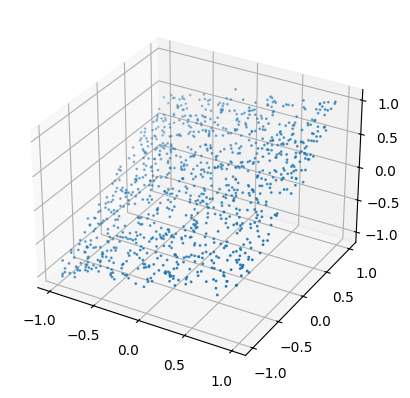

In [29]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X[:,0], X[:,1], X[:,2], s=1)

plt.show()

In [30]:
encoder = keras.models.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(2)
])

decoder = keras.models.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(3)
])

autoencoder = keras.models.Sequential([encoder, decoder])

autoencoder.compile(loss='mse', optimizer=keras.optimizers.SGD(learning_rate=0.1))

- Organizamos o autoencoder e dois subcomponentes, o codificador e o decodificador. Ambos são _Sequential_ com uma única camada _Dense_ cada um.
- O número de saídas é o mesmo de entradas 
- A fim de executar uma simples PCA, não utilizamos nenhuma função de ativação (por isso é um autoencoder linear), veremos autoencoders complexos em breve.

In [31]:
history = autoencoder.fit(X_train, X_train, epochs=20)
codings = encoder.predict(X_train)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2226
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0742
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0588
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0453
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0339
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0249
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0131
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0096
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0071
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024
Epoch 16/20
25/25 ━

Repare que o mesmo conjunto de dados `X_train` é utlizado como entrada e alvo. Plotando os dados em 3D e 2D podemos ver o melhor plano 2D para projetar os dados, preservando o máximo possível de variância nos dados (assim como o PCA)

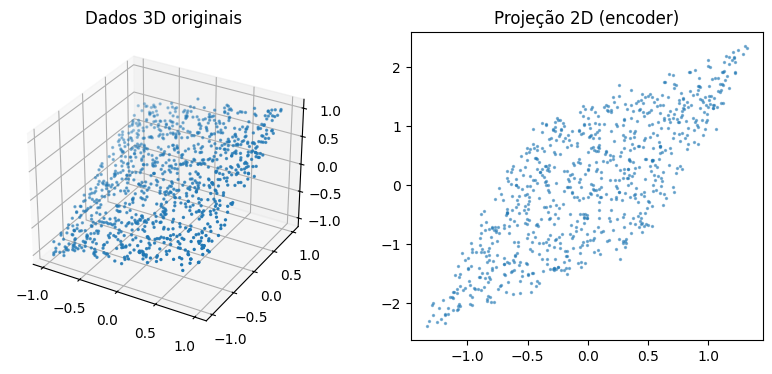

In [36]:
fig = plt.figure(figsize=(10,4))

# 3D - dados originais
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:,0], X[:,1], X[:,2], s=2)
ax1.set_title("Dados 3D originais")

# 2D - projeção aprendida
ax2 = fig.add_subplot(122)
ax2.scatter(codings[:,0], codings[:,1], s=2, alpha=0.5)
ax2.set_title("Projeção 2D (encoder)")

plt.show()

* Você pode considerar autoencoders como uma forma de aprendizado autossupervisionado

# Autoencoders Empilhados
Autoencoders podem ter diversas camadas ocultas. Neste caso, elas se chamam _autoencoders empilhados_ (ou deep autoencoders). Acrescentar mais camadas ajuda o autoencoder a aprender codificações mais complexas.

## Implementando um autoencoder empilhado com Keras
Para implementar, é muito parecido com uma MLP profunda. O código a seguir treina os dados do fashion-MNIST (do capítulo 10, carregado e normalizado), usando ativação SELU (mas não vou rodar o código de treinamento):

In [37]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [38]:
X_train_full.shape

(60000, 28, 28)

In [39]:
X_val, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0 # slice e escalonamento das características de entrada
y_val, y_train = y_train_full[:5000], y_train_full[5000:]

In [40]:
X_test = X_test / 255.0

In [41]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [42]:
stacked_encoder = keras.models.Sequential([
    keras.layers.Input([28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='selu'),
    keras.layers.Dense(30, activation='selu')
])

stacked_decoder = keras.models.Sequential([
    keras.layers.Input([30]),
    keras.layers.Dense(100, activation='selu'),
    keras.layers.Dense(28 * 28, activation='sigmoid'),
    keras.layers.Reshape([28, 28])
])

stacked_ae = keras.models.Sequential([stacked_encoder, stacked_decoder])
stacked_ae.compile(loss='binary_crossentropy', optimizer=keras.optimizers.SGD(learning_rate=1.5))

history = stacked_ae.fit(X_train, X_train, epochs=10, validation_data=[X_val, X_val])

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 0.3383 - val_loss: 0.3109
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 0.3053 - val_loss: 0.2983
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.2980 - val_loss: 0.2917
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.2940 - val_loss: 0.2887
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.2913 - val_loss: 0.2873
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.2894 - val_loss: 0.2854
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 0.2880 - val_loss: 0.2842
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.2868 - val_loss: 0.2832
Epoch 9/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.2859 - val_loss: 0.2826
Epoch 10/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.2851 - val_loss: 0.2812


- Dividimos o encoder e autoencoder em dois submodelos, o codificador e decodificador
- O codificador captura imagens em tons de cinza de 28 x 28 pixels, achata elas para que cada imagems ela representada como um vetor de tamanho 784 e, em seguida processa esses vetores por meio de duas camadas `Dense` de tamanhos decrescentes (100 unidades e depois 30 unidades), ambas usando SELU (talvez queiramos adicionar a inicialização normal LeCun também, porém a rede não é muito profunda, logo isso não fará uma grande diferença). Para cada imagem de entrada, o encoder gera um vetor de tamanho 30.
- O decodificador captura as codificações de tamanho 30 e as processa por meio de duas camadas `Dense` de tamanhos crescentes (100 unidades e 784 unidades), e remodela os vetores finais em arrays de 28 x 28, de modo que as saídas do decodificador tenham o mesmo formato que as entradas do decodificador.
- Ao compilar o autoencoder empilhado, usamos a perda de entropia cruzada binária em vez do erro quadrático médio. Estamos tratando a tarefa de reconstrução como um problema de classificação binária multirrótulo. Cada intensidade de pixel representa a probabilidade que o pixel seja preto.

## Visualizando as reconstruções
Uma forma de assegurar que um autoencoder seja treinado devidamente é comparar as entradas e as saídas.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step


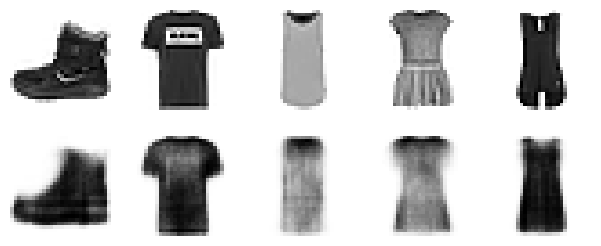

In [43]:
def plot_image(image):
    plt.imshow(image, cmap='binary')
    plt.axis('off')

def show_reconstructions(model, n_images=5):
    reconstructions = model.predict(X_val[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plot_image(X_val[image_index])
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plot_image(reconstructions[image_index])

show_reconstructions(stacked_ae)

As reconstruções são visíveis, mas apresentam um pouco de perdas.

## Visualizando o conjunto de dados Fashion MNIST
Agora que treinamos um autoencoder empilhado, podemos utilizá-lo para reduzir a dimensionalidade do conjunto de dados. Primeiro utilizamos o codificador de nosso autoencoder empilhado a fim de reduzir a dimensionalidade para 30, depois usamos a implementação do algoritmo t-SNE da SKLearn com o intuito de reduzir a dimensionalidade em 2 para a visualização.

In [ ]:
from sklearn.manifold import TSNE

X_val_compressed = stacked_encoder.predict(X_val)
tsne = TSNE()
X_val_2D = tsne.fit_transform(X_val_compressed)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


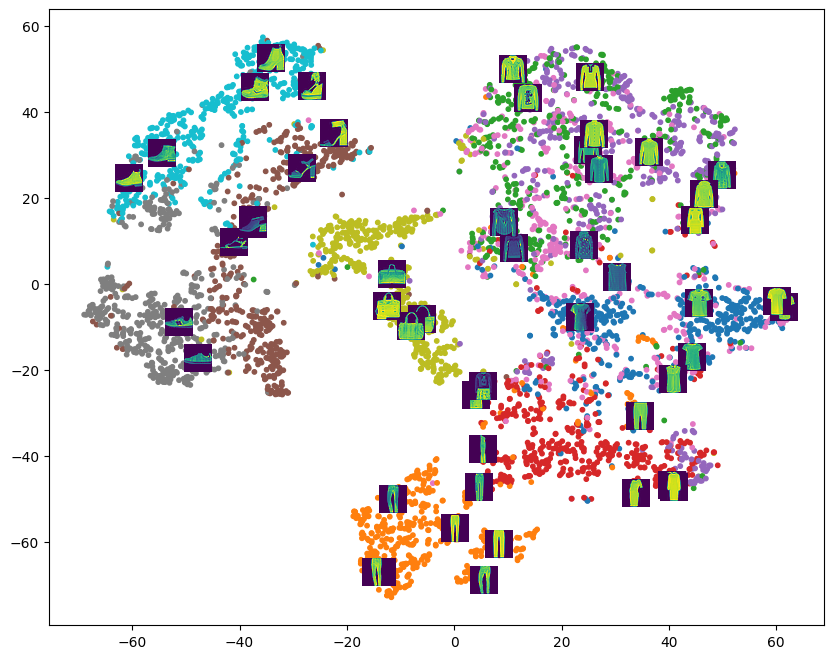

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

plt.figure(figsize=(10,8))

plt.scatter(X_val_2D[:, 0], X_val_2D[:, 1], c=y_val, s=10, cmap='tab10')

for i in range(0, len(X_val_2D), 100):
    img = X_val[i]
    
    imagebox = OffsetImage(img, zoom=.7)
    ab = AnnotationBbox(
        imagebox,
        (X_val_2D[i,0], X_val_2D[i,1]),
        frameon=False
    )
    
    plt.gca().add_artist(ab)


# Amarrar os pesos
Quando um autoencoder é ordenadamente simétrico, como o que acabamos de treinar, uma técninca comum é amarrar os pesos das camadas do decodificador nos pesos das camadas do codificador.

In [ ]:
class DenseTranspose(keras.layers.Layer):
    def __init__(self, dense, activation=None, **kwargs):
        self.dense = dense
        self.activation = keras.activations.get(activation)
        super().__init__(**kwargs)
    def build(self, batch_input_shape):
        self.biases = self.add_weight(name='bias', initializer='zeros', shape=[self.dense.input_shape[-1]])
        super().build(batch_input_shape)
    def call(self, inputs):
        z = tf.matmul(inputs, self.dense.weights[0], transpose_b=True)
        return self.activation(z + self.biases)

Esta camada personalizada funciona como uma camada `Dense` normal, mas usa pesos da camada `Dense` transpostos (definir `tranpose_b=True` é equivalente a transpor o segundo argumento, porém é mais eficiente porque realiza a transposição em tempo real dentro da operação `matmul()`)

Em seguida, podemos construir um novo autoencoder empilhado, bem parecido com o anterior, mas com camadas `Dense` amarradas às camadas `Dense` do codificador:

In [ ]:
dense_1 = keras.layers.Dense(100, activation='selu')
dense_2 = keras.layers.Dense(30, activation='selu')

tied_encoder = keras.models.Sequential([
    keras.layers.Input([28,28]),
    keras.layers.Flatten(),
    dense_1,
    dense_2
])

tied_decoder = keras.models.Sequential([
    DenseTranspose(dense_2, activation='selu'),
    DenseTranspose(dense_1, activation='sigmoid'),
    keras.layers.Reshape([28,28])
])

tied_ae = keras.models.Sequential([tied_encoder, tied_decoder])